# Anomly Detection in Database Logs
Task : To idenfity the anomalies registered in the log as well as their types

[SQL Queries for Dataset Creation](https://github.com/devrimgunduz/pagila/tree/master)

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/query_raw.csv', index_col = 0)
df

,user_id,role,store_id_accessed,query_type,execution_time_ms,rows_returned,queries_in_last_60s,hour_of_day,day_of_week,is_anomaly,anomaly_type
log_id,,,,,,,,,,,
1,7,billing_staff,1,SELECT_PAYMENT,38,7,2,4.0,1.0,True,temporal
2,10,support_staff,1,UPDATE_CUSTOMER,16,1,7,8.0,1.0,False,NaN
3,10,support_staff,1,SELECT_CUSTOMER,24,7,9,8.0,1.0,False,NaN
4,10,support_staff,1,UPDATE_CUSTOMER,15,1,1,8.0,1.0,False,NaN
5,6,billing_staff,1,INSERT_PAYMENT,19,1,5,8.0,1.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
9996,2,analyst,1,SELECT_FILM_DETAILS,33,13,8,17.0,5.0,False,NaN
9997,22,admin,2,UPDATE_STAFF,20,1,1,17.0,5.0,False,NaN
9998,8,support_staff,1,SELECT_RENTAL_STATUS,32,3,7,2.0,6.0,True,temporal


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              10000 non-null  int64  
 1   role                 10000 non-null  object 
 2   store_id_accessed    10000 non-null  int64  
 3   query_type           10000 non-null  object 
 4   execution_time_ms    10000 non-null  int64  
 5   rows_returned        10000 non-null  int64  
 6   queries_in_last_60s  10000 non-null  int64  
 7   hour_of_day          10000 non-null  float64
 8   day_of_week          10000 non-null  float64
 9   is_anomaly           10000 non-null  bool   
 10  anomaly_type         725 non-null    object 
dtypes: bool(1), float64(2), int64(5), object(3)
memory usage: 869.1+ KB


In [4]:
df['is_anomaly'].value_counts()

,count
is_anomaly,
False,9275
True,725


In [5]:
df['anomaly_type']= df['anomaly_type'].fillna('0')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              10000 non-null  int64  
 1   role                 10000 non-null  object 
 2   store_id_accessed    10000 non-null  int64  
 3   query_type           10000 non-null  object 
 4   execution_time_ms    10000 non-null  int64  
 5   rows_returned        10000 non-null  int64  
 6   queries_in_last_60s  10000 non-null  int64  
 7   hour_of_day          10000 non-null  float64
 8   day_of_week          10000 non-null  float64
 9   is_anomaly           10000 non-null  bool   
 10  anomaly_type         10000 non-null  object 
dtypes: bool(1), float64(2), int64(5), object(3)
memory usage: 869.1+ KB


In [7]:
df['is_anomaly'] = df['is_anomaly'].map({True: 1, False: 0})

In [8]:
df['is_anomaly']

,is_anomaly
log_id,
1,1
2,0
3,0
4,0
5,0
...,...
9996,0
9997,0
9998,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              10000 non-null  int64  
 1   role                 10000 non-null  object 
 2   store_id_accessed    10000 non-null  int64  
 3   query_type           10000 non-null  object 
 4   execution_time_ms    10000 non-null  int64  
 5   rows_returned        10000 non-null  int64  
 6   queries_in_last_60s  10000 non-null  int64  
 7   hour_of_day          10000 non-null  float64
 8   day_of_week          10000 non-null  float64
 9   is_anomaly           10000 non-null  int64  
 10  anomaly_type         10000 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 937.5+ KB


In [10]:
df['is_anomaly'].value_counts()

,count
is_anomaly,
0,9275
1,725


## Feature Engineering

In [11]:
df['is_off_hours'] = (df['hour_of_day'].between(0,5)).astype(int)
df['is_weekend'] = (df['day_of_week'].isin([0,6])).astype(int)

In [12]:
df['execution_time_zscore'] = df.groupby('query_type')['execution_time_ms'].transform(
    lambda x: (x - x.mean()) / x.std()
)

In [13]:
user_home_store = df.groupby('user_id')['store_id_accessed'].agg(
    lambda x: x.mode()[0]
)
df['home_store'] = df['user_id'].map(user_home_store)
df['is_cross_store'] = (df['store_id_accessed'] != df['home_store']).astype(int)
df.drop(columns=['home_store'], inplace=True)

In [14]:
risk_map = {
    'SELECT_ALL_TABLES': 3,'SELECT_ALL_PAYMENTS': 3,'SELECT_STAFF_ACTIVITY': 3,'SELECT_SYSTEM_LOGS': 3,
    'SELECT_REVENUE_REPORT': 2,'SELECT_RENTAL_AUDIT': 2,'UPDATE_STAFF': 2,'INSERT_PAYMENT': 2,
    'UPDATE_CUSTOMER': 1,'SELECT_CUSTOMER': 1,'SELECT_PAYMENT': 1,'SELECT_RENTAL_STATUS': 1,
    'SELECT_CUSTOMER_HISTORY': 1,'SELECT_FILM_DETAILS': 1,'SELECT_RENTAL_SUMMARY': 1,'SELECT_STORE_SUMMARY': 1,
    'SELECT_INVENTORY': 1
}
df['query_risk_score'] = df['query_type'].map(risk_map).fillna(1)

## Feature Encoding

In [15]:
df = pd.get_dummies(df, columns=['query_type', 'role'], drop_first=False)

In [16]:
df['store_id_accessed'] = df['store_id_accessed'].map({1: 0, 2: 1})

In [17]:
labels = df[['is_anomaly', 'anomaly_type']].copy()

In [18]:
df_features = df.drop(columns=['is_anomaly', 'anomaly_type'])

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_features),
    columns=df_features.columns
)

In [20]:
df_scaled

,user_id,store_id_accessed,execution_time_ms,rows_returned,queries_in_last_60s,hour_of_day,day_of_week,is_off_hours,is_weekend,execution_time_zscore,...,query_type_SELECT_STORE_SUMMARY,query_type_SELECT_SYSTEM_LOGS,query_type_UPDATE_CUSTOMER,query_type_UPDATE_STAFF,role_admin,role_analyst,role_auditor,role_billing_staff,role_manager,role_support_staff
0,-0.716273,-0.992627,-0.356503,-0.153805,-1.339967,-2.744385,-1.408054,9.353907,-0.119590,-0.256113,...,-0.166898,-0.18328,-0.316593,-0.174651,-0.316402,-0.474384,-0.323617,1.661995,-0.304004,-0.623764
1,-0.239975,-0.992627,-0.506969,-0.158269,-0.105088,-1.440360,-1.408054,-0.106907,-0.119590,0.005916,...,-0.166898,-0.18328,3.158631,-0.174651,-0.316402,-0.474384,-0.323617,-0.601687,-0.304004,1.603170
2,-0.239975,-0.992627,-0.452255,-0.153805,0.388863,-1.440360,-1.408054,-0.106907,-0.119590,-0.367796,...,-0.166898,-0.18328,-0.316593,-0.174651,-0.316402,-0.474384,-0.323617,-0.601687,-0.304004,1.603170
3,-0.239975,-0.992627,-0.513809,-0.158269,-1.586942,-1.440360,-1.408054,-0.106907,-0.119590,-0.113854,...,-0.166898,-0.18328,3.158631,-0.174651,-0.316402,-0.474384,-0.323617,-0.601687,-0.304004,1.603170
4,-0.875039,-0.992627,-0.486451,-0.158269,-0.599040,-1.440360,-1.408054,-0.106907,-0.119590,-0.218987,...,-0.166898,-0.18328,-0.316593,-0.174651,-0.316402,-0.474384,-0.323617,1.661995,-0.304004,-0.623764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.510103,-0.992627,-0.390700,-0.149340,0.141888,1.493695,1.367941,-0.106907,-0.119590,0.092119,...,-0.166898,-0.18328,-0.316593,-0.174651,-0.316402,2.107999,-0.323617,-0.601687,-0.304004,-0.623764
9996,1.665217,1.007428,-0.479612,-0.158269,-1.586942,1.493695,1.367941,-0.106907,-0.119590,-0.066678,...,-0.166898,-0.18328,-0.316593,5.725713,3.160540,-0.474384,-0.323617,-0.601687,-0.304004,-0.623764
9997,-0.557507,-0.992627,-0.397540,-0.156781,-0.105088,-3.396397,2.061939,9.353907,8.361937,-0.512648,...,-0.166898,-0.18328,-0.316593,-0.174651,-0.316402,-0.474384,-0.323617,-0.601687,-0.304004,1.603170
9998,-0.398741,-0.992627,-0.527488,-0.158269,1.129790,-3.070391,2.061939,9.353907,8.361937,-0.353396,...,-0.166898,-0.18328,3.158631,-0.174651,-0.316402,-0.474384,-0.323617,-0.601687,-0.304004,1.603170


# Model Training
1. Isolation Forest
2. DBSCAN
3. OneClassSVM

In [21]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, classification_report

In [22]:
df_scaled = df_scaled.reset_index(drop=True)
labels = labels.reset_index(drop=True)

In [23]:
normal_mask = labels['is_anomaly'] == False
X_train = df_scaled[normal_mask]
X_full = df_scaled

In [24]:
X_train.shape

(9275, 35)

In [25]:
X_full.shape

(10000, 35)

# Isolation Forest
- IsolationForest returns 1 for normal, -1 for anomaly

In [26]:
# Core behavioral features only — exclude one-hot encoded columns
# These are the features that directly capture anomalous behavior
core_features = [
    'execution_time_ms',
    'execution_time_zscore',
    'rows_returned',
    'queries_in_last_60s',
    'hour_of_day',
    'day_of_week',
    'is_off_hours',
    'is_weekend',
    'is_cross_store',
    'query_risk_score',
    'user_id',
    'store_id_accessed'
]

X_train_core = df_scaled[core_features][normal_mask]
X_full_core = df_scaled[core_features]

# Retrain Isolation Forest on core features only
iso_core = IsolationForest(
    n_estimators=200,      # more trees for stability
    contamination=0.0725,
    random_state=42,
    max_features=0.8       # use 80% of features per tree
)
iso_core.fit(X_train_core)
iso_preds_core = iso_core.predict(X_full_core)
iso_preds_bool = iso_preds_core == -1

print(f"Isolation Forest (core features): {iso_preds_bool.sum()} anomalies flagged")

Isolation Forest (core features): 843 anomalies flagged


# DBSCAN
DBSCAN returns -1 for noise points (anomalies), cluster number for normal

In [27]:
dbscan = DBSCAN(eps=3.0,min_samples=10,n_jobs=-1)
dbscan_preds = dbscan.fit_predict(X_full)
dbscan_preds_bool = dbscan_preds == -1

# One Class SVM
OneClassSVM returns 1 for normal, -1 for anomaly

In [28]:
ocsvm_tuned = OneClassSVM(
    kernel='rbf',
    nu=0.04,
    gamma='scale'
)
ocsvm_tuned.fit(X_train[core_features] if hasattr(X_train, 'columns')
                else pd.DataFrame(X_train, columns=df_scaled.columns)[core_features])

# Use core features for OCSVM too
ocsvm_preds = ocsvm_tuned.predict(X_full_core)
ocsvm_preds_bool = ocsvm_preds == -1

print(f"One-Class SVM (tuned): {ocsvm_preds_bool.sum()} anomalies flagged")

One-Class SVM (tuned): 1102 anomalies flagged


In [29]:
y_true = labels['is_anomaly'].values

print("\n" + "="*60)
print("ISOLATION FOREST — Overall")
print("="*60)
print(classification_report(y_true, iso_preds_bool,
      target_names=['Normal', 'Anomaly']))

print("\n" + "="*60)
print("DBSCAN — Overall")
print("="*60)
print(classification_report(y_true, dbscan_preds_bool,
      target_names=['Normal', 'Anomaly']))

print("\n" + "="*60)
print("ONE-CLASS SVM — Overall")
print("="*60)
print(classification_report(y_true, ocsvm_preds_bool,
      target_names=['Normal', 'Anomaly']))


ISOLATION FOREST — Overall
              precision    recall  f1-score   support

      Normal       0.94      0.93      0.93      9275
     Anomaly       0.20      0.23      0.22       725

    accuracy                           0.88     10000
   macro avg       0.57      0.58      0.58     10000
weighted avg       0.89      0.88      0.88     10000


DBSCAN — Overall
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98      9275
     Anomaly       1.00      0.58      0.74       725

    accuracy                           0.97     10000
   macro avg       0.98      0.79      0.86     10000
weighted avg       0.97      0.97      0.97     10000


ONE-CLASS SVM — Overall
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98      9275
     Anomaly       0.66      1.00      0.79       725

    accuracy                           0.96     10000
   macro avg       0.83      0.98      0.89     10000
wei

In [30]:
anomaly_types = ['security', 'temporal', 'performance']
models = {
    'Isolation Forest': iso_preds_bool,
    'DBSCAN': dbscan_preds_bool,
    'One-Class SVM': ocsvm_preds_bool
}

print("\n" + "="*60)
print("F1 SCORES BY ANOMALY TYPE")
print("="*60)
results = []
for model_name, preds in models.items():
    for atype in anomaly_types:
        # Filter to only rows that are either normal OR this anomaly type
        mask = (labels['is_anomaly'] == False) | (labels['anomaly_type'] == atype)
        y_true_filtered = labels['is_anomaly'][mask].values
        y_pred_filtered = preds[mask]
        f1 = f1_score(y_true_filtered, y_pred_filtered)
        results.append({
            'Model': model_name,
            'Anomaly Type': atype,
            'F1 Score': round(f1, 4)
        })
        print(f"{model_name:20s} | {atype:12s} | F1 = {f1:.4f}")


F1 SCORES BY ANOMALY TYPE
Isolation Forest     | security     | F1 = 0.0322
Isolation Forest     | temporal     | F1 = 0.0461
Isolation Forest     | performance  | F1 = 0.2381
DBSCAN               | security     | F1 = 0.7138
DBSCAN               | temporal     | F1 = 0.9716
DBSCAN               | performance  | F1 = 0.5282
One-Class SVM        | security     | F1 = 0.4912
One-Class SVM        | temporal     | F1 = 0.5351
One-Class SVM        | performance  | F1 = 0.6336


In [31]:
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
results_df = pd.DataFrame(results)
print(results_df.pivot(index='Model', columns='Anomaly Type', values='F1 Score'))


SUMMARY TABLE
Anomaly Type      performance  security  temporal
Model                                            
DBSCAN                 0.5282    0.7138    0.9716
Isolation Forest       0.2381    0.0322    0.0461
One-Class SVM          0.6336    0.4912    0.5351


In [32]:
print("Isolation Forest predictions:", iso_preds_bool.sum(), "anomalies flagged")
print("DBSCAN predictions:", dbscan_preds_bool.sum(), "anomalies flagged")
print("One-Class SVM predictions:", ocsvm_preds_bool.sum(), "anomalies flagged")
print("True anomalies:", y_true.sum())
print("Results dataframe shape:", results_df.shape)
print(results_df)

Isolation Forest predictions: 843 anomalies flagged
DBSCAN predictions: 423 anomalies flagged
One-Class SVM predictions: 1102 anomalies flagged
True anomalies: 725
Results dataframe shape: (9, 3)
              Model Anomaly Type  F1 Score
0  Isolation Forest     security    0.0322
1  Isolation Forest     temporal    0.0461
2  Isolation Forest  performance    0.2381
3            DBSCAN     security    0.7138
4            DBSCAN     temporal    0.9716
5            DBSCAN  performance    0.5282
6     One-Class SVM     security    0.4912
7     One-Class SVM     temporal    0.5351
8     One-Class SVM  performance    0.6336


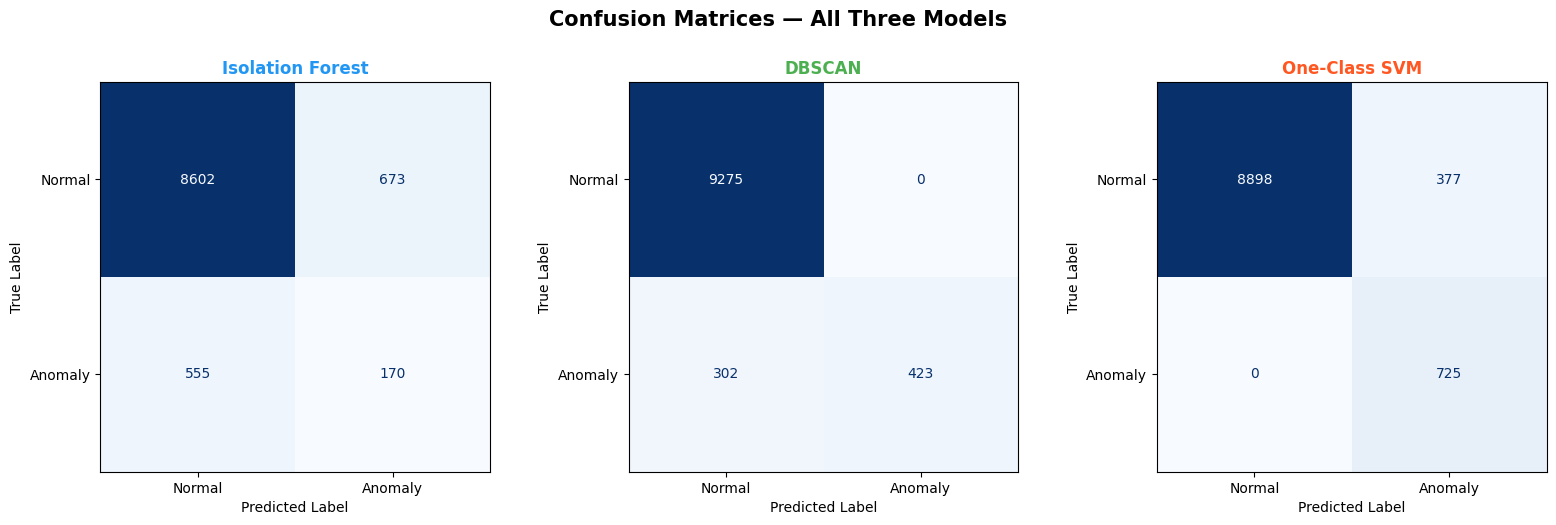

Saved: confusion_matrices.png


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

model_names = ['Isolation Forest', 'DBSCAN', 'One-Class SVM']
all_preds = [iso_preds_bool, dbscan_preds_bool, ocsvm_preds_bool]
colors = ['#2196F3', '#4CAF50', '#FF5722']
anomaly_types = ['security', 'temporal', 'performance']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Three Models', fontsize=15, fontweight='bold', y=1.02)

for ax, name, preds, color in zip(axes, model_names, all_preds, colors):
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

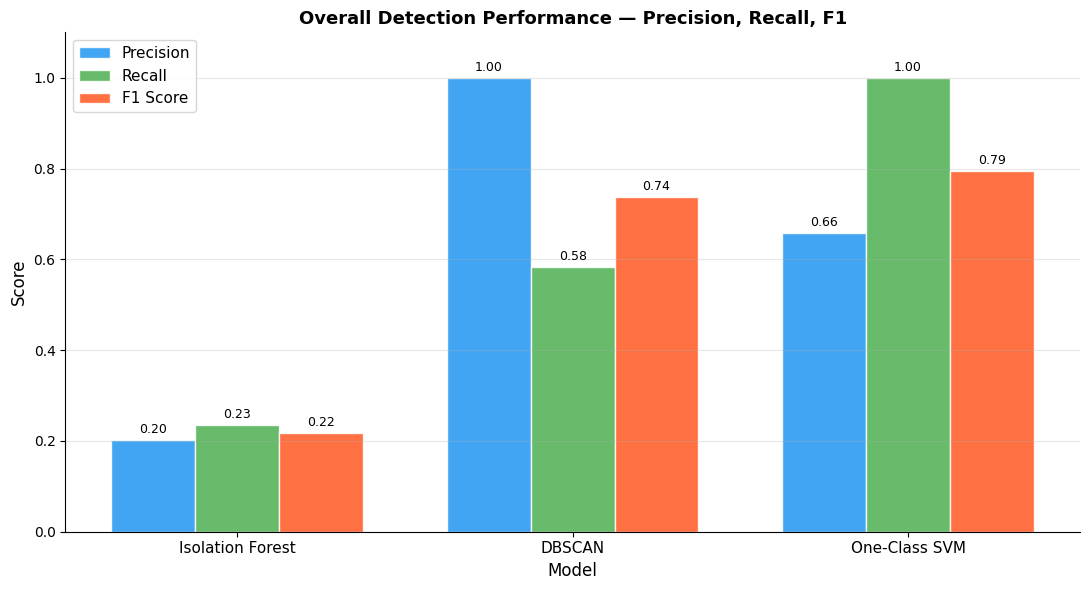

Saved: overall_performance.png


In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_data = []
for name, preds in zip(model_names, all_preds):
    metrics_data.append({
        'Model': name,
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall':    recall_score(y_true, preds, zero_division=0),
        'F1':        f1_score(y_true, preds, zero_division=0)
    })

metrics_df = pd.DataFrame(metrics_data)
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width, metrics_df['Precision'], width,
               label='Precision', color='#2196F3', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x,          metrics_df['Recall'],    width,
               label='Recall',    color='#4CAF50', alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + width,  metrics_df['F1'],        width,
               label='F1 Score',  color='#FF5722', alpha=0.85, edgecolor='white')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Overall Detection Performance — Precision, Recall, F1',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('overall_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overall_performance.png")


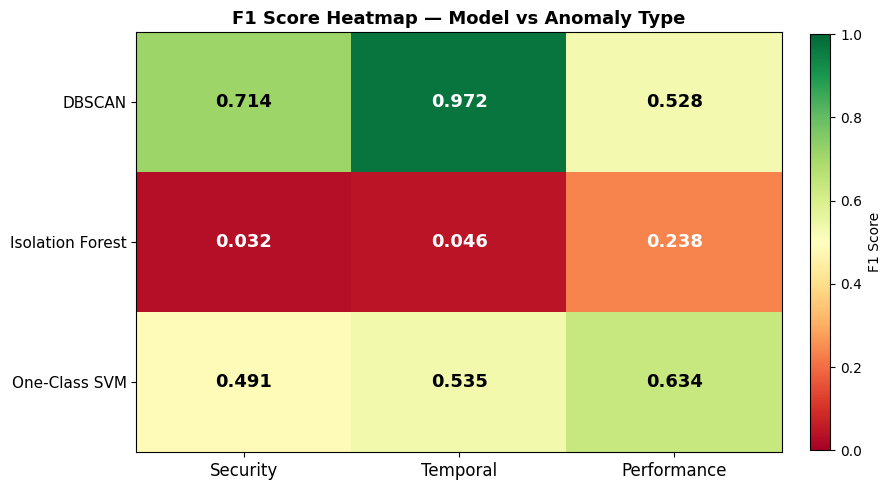

Saved: f1_heatmap.png


In [36]:
pivot = results_df.pivot(index='Model', columns='Anomaly Type', values='F1 Score')
pivot = pivot[['security', 'temporal', 'performance']]  # consistent column order

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(['Security', 'Temporal', 'Performance'], fontsize=12)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)
ax.set_title('F1 Score Heatmap — Model vs Anomaly Type',
             fontsize=13, fontweight='bold')

# Annotate each cell with the F1 value
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        text_color = 'white' if val < 0.35 or val > 0.75 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=13, fontweight='bold', color=text_color)

plt.colorbar(im, ax=ax, label='F1 Score', fraction=0.03, pad=0.04)
plt.tight_layout()
plt.savefig('f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f1_heatmap.png")

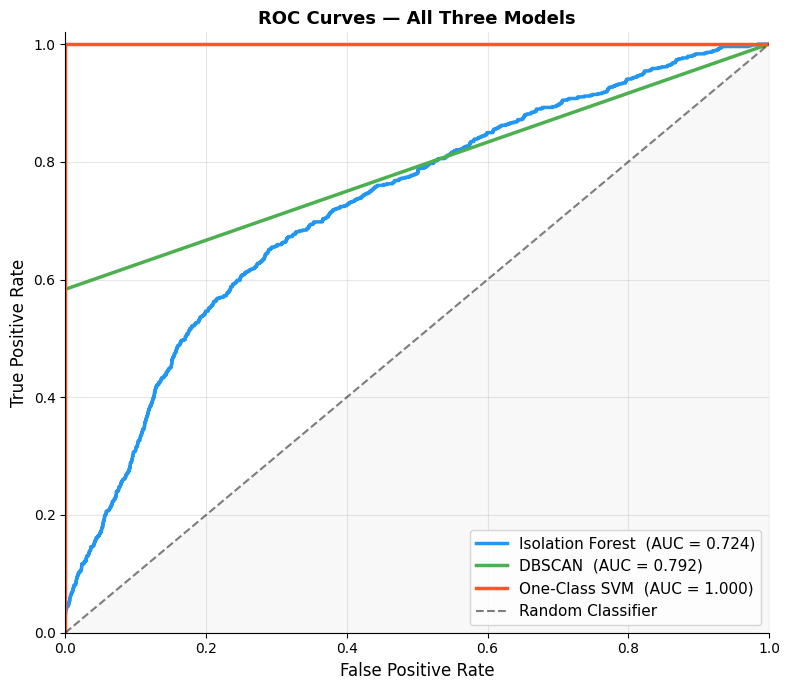

Saved: roc_curves.png


In [37]:
fig, ax = plt.subplots(figsize=(8, 7))

roc_data = [
    ('Isolation Forest', iso_core.decision_function(X_full_core), '#2196F3'),
    ('DBSCAN',           dbscan_preds_bool.astype(float),          '#4CAF50'),
    ('One-Class SVM',    ocsvm_tuned.decision_function(X_full_core), '#FF5722'),
]

for name, scores, color in roc_data:
    # For anomaly models, lower score = more anomalous, so negate
    score_adjusted = -scores if name != 'DBSCAN' else scores
    fpr, tpr, _ = roc_curve(y_true, score_adjusted)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Three Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")

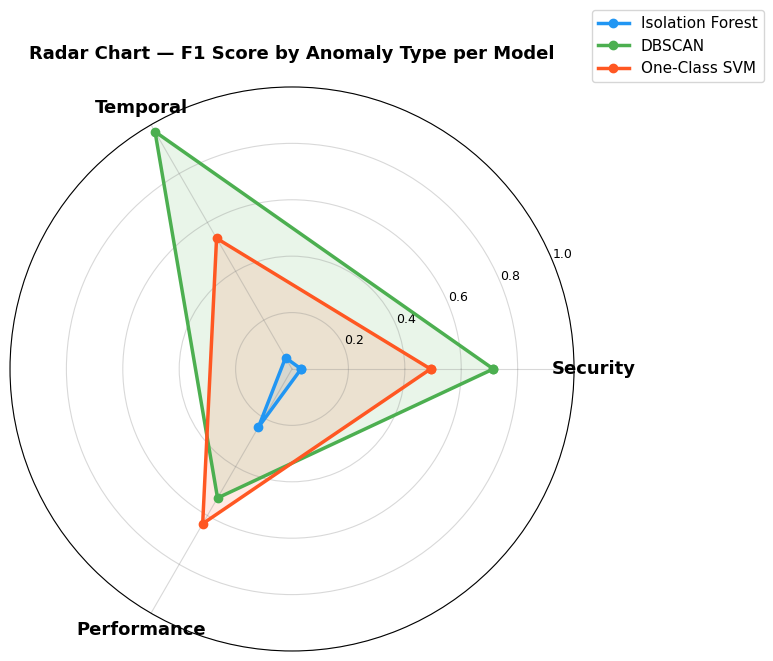

Saved: radar_chart.png


In [38]:
categories = ['Security', 'Temporal', 'Performance']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (name, color) in enumerate(zip(model_names, colors)):
    values = results_df[results_df['Model'] == name]['F1 Score'].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, color=color, label=name)
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.set_title('Radar Chart — F1 Score by Anomaly Type per Model',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(color='gray', alpha=0.3)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: radar_chart.png")